# **DHS Kenya 2022 Dataset Exploratory Data Analysis**

## **Project:** CancerPath-Africa 
## **Notebook:** DHS Kenya EDA 
## **Objective:** Load, explore, and prepare the Kenya DHS 2022 Individual Recode dataset for;
1. ### Cervical Cancer Risk Screener (Agent 1 )

1. ### Referral Compliance Predictor (Agent 4).
## **Dataset:** Kenya DHS 2022 Individual Recode (KEIR8CFL.DTA) with 32,156 women aged 15–49

---

## Loading Libraries and DHS Individual Recode Dataset

I will load the Kenya DHS 2022 Individual Recode file ( Stata format) using  via pandas. This file contains responses from **32,156 women aged 15–49** across Kenya and is the primary data source for both Agent 1 and Agent 4.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
sys.path.append('..')

from config.config import (
    DHS_INDIVIDUAL, DHS_HOUSEHOLD, 
    DHS_HOUSEHOLD_MEMBER, DHS_GEOSPATIAL_COV
)

# Loading the Individual Recode dataset (DHS_INDIVIDUAL)
df_ir = pd.read_stata(DHS_INDIVIDUAL, convert_categoricals=False)

print("Shape:", df_ir.shape)
print("\nFirst 5 columns:", df_ir.columns[:5].tolist())
print("Total columns:", len(df_ir.columns))

Shape: (32156, 5925)

First 5 columns: ['caseid', 'v000', 'v001', 'v002', 'v003']
Total columns: 5925


## Extracting Variable Labels

The DHS Individual Recode contains **5,925 variables** with cryptic names. I will extract the Stata variable labels to create a readable data dictionary, which i will save as a CSV for reference throughout the project.

This step is essential before any variable selection because without labels, the coded variable names are uninterpretable.

In [2]:
# Getting variable labels from Stata file
df_ir_labels = pd.read_stata(DHS_INDIVIDUAL, iterator=True)
variable_labels = df_ir_labels.variable_labels()

# Displaying all variable labels
labels_df = pd.DataFrame(
    list(variable_labels.items()), 
    columns=['Variable', 'Label']
)

print(f"Total variables: {len(labels_df)}")
print("\nFirst 20 variables:")
print(labels_df.head(20).to_string())

# Saving labels for reference
labels_df.to_csv('../data/processed/dhs_ir_variable_labels.csv', index=False)
print("\nAll variable labels saved to data/processed/dhs_ir_variable_labels.csv")

Total variables: 5925

First 20 variables:
   Variable                                          Label
0    caseid                            case identification
1      v000                         country code and phase
2      v001                                 cluster number
3      v002                               household number
4      v003                       respondent's line number
5      v004                             ultimate area unit
6      v005  women's individual sample weight (6 decimals)
7      v006                             month of interview
8      v007                              year of interview
9      v008                        date of interview (cmc)
10    v008a       date of interview century day code (cdc)
11     v009                    respondent's month of birth
12     v010                     respondent's year of birth
13     v011                            date of birth (cmc)
14     v012                       respondent's current age
15     v013  

## Keyword Search for Relevant Variables

With 5,925 variables, manual browsing is impractical. I will define a keyword search function and systematically search for variables related to our key topics:

- **Cancer / Cervical** → Target variables for Agent 1
- **HIV** → Risk factor variables
- **Insurance / Distance / Facility** → Barrier variables for Agent 4
- **Wealth / Education** → Socioeconomic features
- **Health-seeking behaviour** → Compliance proxy variables

Results are printed for inspection and cross-referenced with the saved variable labels CSV.

In [3]:
# Searching for relevant variables by keyword
def search_variables(keyword, labels_df):
    mask = labels_df['Label'].str.contains(
        keyword, case=False, na=False
    )
    return labels_df[mask]

# Searching for our key variable groups
searches = {
    'cancer':       search_variables('cancer', labels_df),
    'cervical':     search_variables('cervical', labels_df),
    'screening':    search_variables('screening', labels_df),
    'HIV':          search_variables('hiv', labels_df),
    'insurance':    search_variables('insurance', labels_df),
    'distance':     search_variables('distance', labels_df),
    'facility':     search_variables('facility', labels_df),
    'seek':         search_variables('seek', labels_df),
    'reason':       search_variables('reason not', labels_df),
    'wealth':       search_variables('wealth', labels_df),
    'education':    search_variables('education', labels_df),
}

# Printing results for each search
for topic, result in searches.items():
    print(f"\n{'='*50}")
    print(f"Topic: {topic.upper()} ; {len(result)} variables found")
    print(result.to_string())


Topic: CANCER ; 14 variables found
     Variable                                                                             Label
4850    v484a                               breasts examined for cancer by health care provider
4851    v484b                           ever tested for cervical cancer by health care provider
5619    chd15  na - ever been told by a doctor or other healthcare worker that you have cancer 
5620    chd16                          na - are you receiving any treatment for cancer or tumor
5628    chd24                                                na - ever heard of cervical cancer
5629    chd25                                   na - ever heard of any test for cervical cancer
5630    chd27  na - ever been tested by a doctor or other healthcare worker for cervical cancer
5631    chd28                                        na - years since last cervical cancer test
5632    chd29                                               na - result of last cervical cancer
5668

## Initial Variable Selection and Missingness Assessment

Based on the keyword search results, I will select the most relevant variables for Agent 1 and Agent 4. I will then assess missing data patterns to understand data quality before committing to a final feature set.

**Variables selected cover:**
- Cervical cancer testing history and diagnosis
- HIV testing and status
- Health insurance coverage
- Distance and access barriers
- Wealth index and education
- Health facility utilisation

In [4]:
# Defining variables for each agent
agent1_vars = [
    'caseid', 'v001', 'v002', 'v003',  # identifiers
    'v012',   # age
    'v106',   # education level
    'v190',   # wealth index
    'v190a',  # wealth index urban/rural
    'v481',   # health insurance
    'v484b',  # ever tested for cervical cancer
    's1105a', # told they have cervical cancer
    's1105b', # receiving treatment for cervical cancer
    'chd24',  # ever heard of cervical cancer
    'chd27',  # ever tested for cervical cancer
    'chd29',  # result of last cervical cancer test
    'v781',   # ever tested for HIV
    'v861',   # result of HIV test
]

agent4_vars = [
    'caseid', 'v001', 'v002', 'v003',  # identifiers
    'v012',   # age
    'v106',   # education level
    'v190',   # wealth index
    'v190a',  # urban/rural
    'v481',   # insurance coverage
    'v467d',  # distance to health facility
    'v483a',  # minutes to nearest facility
    'v483b',  # mode of transport
    'v394',   # visited health facility last 12 months
    'mh19_1', # denied services for lack of money
    'mh20_1', # delayed leaving facility due to payment
    'd119y',  # did not seek help from anyone
]

# Combining all unique variables
all_vars = list(set(agent1_vars + agent4_vars))

# Extracting from the main dataframe
df_selected = df_ir[all_vars].copy()

print("Selected variables shape:", df_selected.shape)
print("\nMissing values summary:")
missing = df_selected.isnull().sum()
missing_pct = (missing / len(df_selected) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Saving extracted dataset
df_selected.to_csv('../data/processed/dhs_extracted_variables.csv', index=False)
print("\nSaved to data/processed/dhs_extracted_variables.csv")

Selected variables shape: (32156, 24)

Missing values summary:
        Missing Count  Missing %
chd27           32156     100.00
mh19_1          32156     100.00
chd24           32156     100.00
v481            32156     100.00
mh20_1          32156     100.00
chd29           32156     100.00
s1105b          32128      99.91
d119y           25816      80.28
v861            18399      57.22
v483a           15255      47.44
v484b           15255      47.44
s1105a          15255      47.44
v467d           15255      47.44
v483b           15255      47.44
v394            15254      47.44
v781            15255      47.44

Saved to data/processed/dhs_extracted_variables.csv


## Investigating Missing Data Patterns

The initial missingness check revealed that several key variables have **47% or 100% missing values**. Before dropping variables, I will investigate whether this is due to:

1. **DHS survey module subsampling** as some questions are only asked to a subset of respondents by design
2. **Special missing codes** (9, 99, 999) that were not converted during loading
3. **Module not administered** in the Kenya 2022 survey

Understanding the missingness mechanism determines the appropriate response.

In [5]:
# Checking if these variables exist but are just encoded differently as DHS often uses special missing codes like 9, 99, 999 instead of NaN

print("Checking value distributions for key variables:\n")

check_vars = ['v484b', 's1105a', 'v781', 'v861', 
              'v467d', 'v394', 'v190', 'v106', 'v012']

for var in check_vars:
    print(f"\n{var} : {labels_df[labels_df['Variable']==var]['Label'].values[0]}")
    print(df_ir[var].value_counts(dropna=False).head(10))

# Also checking the chd variables more carefully
print("\n\nChecking chd variables (100% missing):")
chd_vars = [col for col in df_ir.columns if col.startswith('chd')]
print(f"Total chd variables in dataset: {len(chd_vars)}")
print("chd variable names:", chd_vars[:20])

# Checking if v481 exists under different name
print("\n\nSearching for insurance variables:")
insurance_vars = [col for col in df_ir.columns if 'v481' in col.lower()]
print("Insurance related columns:", insurance_vars)

Checking value distributions for key variables:


v484b : ever tested for cervical cancer by health care provider
v484b
NaN    15255
0.0    14473
1.0     2351
8.0       77
Name: count, dtype: int64

s1105a : told they have cervical cancer
s1105a
0.0    16873
NaN    15255
1.0       28
Name: count, dtype: int64

v781 : ever been tested for hiv
v781
NaN    15255
1.0    13815
0.0     3086
Name: count, dtype: int64

v861 : result of hiv test
v861
NaN    18399
2.0    13357
1.0      332
5.0       41
4.0       22
3.0        5
Name: count, dtype: int64

v467d : getting medical help for self: distance to health facility
v467d
NaN    15255
2.0    12312
1.0     4589
Name: count, dtype: int64

v394 : visited health facility last 12 months
v394
NaN    15254
1.0     8660
0.0     8242
Name: count, dtype: int64

v190 : wealth index combined
v190
4    7160
1    7073
3    6345
5    5836
2    5742
Name: count, dtype: int64

v106 : highest educational level
v106
1    11807
2    11634
3     4879
0     3836


## Deep Missingness Investigation

I will check the  chronic disease and  insurance variable groups more carefully to determine if they contain special codes or are genuinely empty. I will also analyse the 47% missing pattern to confirm it is a **survey design subsampling feature** rather than random missingness.

In [6]:
# Checking chd variables for special codes
print("Checking chd variables raw values:")
for var in ['chd15', 'chd24', 'chd27', 'chd28', 'chd29']:
    print(f"\n{var}:")
    print(df_ir[var].value_counts(dropna=False).head(10))

# Checking v481 raw values
print("\n\nChecking v481 insurance raw values:")
for var in ['v481', 'v481a', 'v481b', 'v481c', 'v481d']:
    print(f"\n{var}:")
    print(df_ir[var].value_counts(dropna=False).head(10))

# Identifying the 15255 missing pattern
print("\n\nInvestigating the 47% missing pattern:")
missing_mask = df_ir['v484b'].isna()
print(f"Rows with v484b missing: {missing_mask.sum()}")
print(f"\nAge distribution of missing vs present:")
print(pd.DataFrame({
    'Missing v484b': df_ir[missing_mask]['v012'].describe(),
    'Has v484b': df_ir[~missing_mask]['v012'].describe()
}))

# Checking what other variables have exactly 15255 missing
exactly_15255 = [col for col in df_ir.columns 
                 if df_ir[col].isna().sum() == 15255]
print(f"\nVariables with exactly 15255 missing: {len(exactly_15255)}")
print("First 10:", exactly_15255[:10])

Checking chd variables raw values:

chd15:
chd15
NaN    32156
Name: count, dtype: int64

chd24:
chd24
NaN    32156
Name: count, dtype: int64

chd27:
chd27
NaN    32156
Name: count, dtype: int64

chd28:
chd28
NaN    32156
Name: count, dtype: int64

chd29:
chd29
NaN    32156
Name: count, dtype: int64


Checking v481 insurance raw values:

v481:
v481
NaN    32156
Name: count, dtype: int64

v481a:
v481a
NaN    32156
Name: count, dtype: int64

v481b:
v481b
NaN    32156
Name: count, dtype: int64

v481c:
v481c
NaN    32156
Name: count, dtype: int64

v481d:
v481d
NaN    32156
Name: count, dtype: int64


Investigating the 47% missing pattern:
Rows with v484b missing: 15255

Age distribution of missing vs present:
       Missing v484b     Has v484b
count   15255.000000  16901.000000
mean       29.118912     29.164014
std         9.556023      9.537504
min        15.000000     15.000000
25%        21.000000     21.000000
50%        28.000000     28.000000
75%        36.000000     36.000000
max   

## Rebuilding Clean Dataset

**Findings from investigation:**
- The variables are **genuinely empty** as these modules were not administered in Kenya 2022
- The 47% missing pattern affects exactly **15,255 respondents** with identical age distributions to the non-missing group, confirming it is a **deliberate survey subsample design**
- I will retain the **16,901 women** who completed the health module as our analytical sample

This sample size remains large and representative for machine learning purposes.

In [7]:
# Dropping completely empty variables
drop_vars = [
    'chd24', 'chd27', 'chd29',  # completely empty
    'v481',                       # completely empty
    'mh19_1', 'mh20_1',          # completely empty
    's1105b',                     # 99.91% missing
    'd119y',                      # 80% missing
]

# Revised variable lists
agent1_vars_clean = [
    'caseid', 'v001', 'v002', 'v003',  # identifiers
    'v012',   # age
    'v106',   # education level
    'v190',   # wealth index
    'v190a',  # urban/rural
    'v484b',  # ever tested for cervical cancer
    's1105a', # told they have cervical cancer
    'v781',   # ever tested for HIV
    'v861',   # result of HIV test
]

agent4_vars_clean = [
    'caseid', 'v001', 'v002', 'v003',  # identifiers
    'v012',   # age
    'v106',   # education level
    'v190',   # wealth index
    'v190a',  # urban/rural
    'v467d',  # distance to health facility
    'v483a',  # minutes to nearest facility
    'v483b',  # mode of transport
    'v394',   # visited health facility last 12 months
    'v781',   # ever tested for HIV
]

# Combining all unique variables
all_vars_clean = list(set(agent1_vars_clean + agent4_vars_clean))

# Extracting and filtering to subsample with health module data
df_clean = df_ir[all_vars_clean].copy()
df_clean = df_clean[df_clean['v484b'].notna()].copy()

print("Clean dataset shape:", df_clean.shape)
print("\nMissing values after cleaning:")
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Value distributions for key target variables
print("\n\nTarget variable distributions:")
print("\nv484b ; Ever tested for cervical cancer:")
print(df_clean['v484b'].value_counts())
print("\ns1105a ; Told they have cervical cancer:")
print(df_clean['s1105a'].value_counts())
print("\nv467d ; Distance to health facility:")
print(df_clean['v467d'].value_counts())

Clean dataset shape: (16901, 16)

Missing values after cleaning:
      Missing Count  Missing %
v861           3144       18.6


Target variable distributions:

v484b ; Ever tested for cervical cancer:
v484b
0.0    14473
1.0     2351
8.0       77
Name: count, dtype: int64

s1105a ; Told they have cervical cancer:
s1105a
0.0    16873
1.0       28
Name: count, dtype: int64

v467d ; Distance to health facility:
v467d
2.0    12312
1.0     4589
Name: count, dtype: int64


## Defining Target Variables

Engineering two binary target variables from the available DHS data:

**Agent 1 — Cervical Cancer Screening Non-Uptake:**
-  → Never screened (needs intervention) will be a **positive class**
-  → Has been screened will be a **negative class**
- Source variable:  (ever tested for cervical cancer by health care provider)

**Agent 4 — Referral Compliance Barrier:**
-  → Distance is a big problem (low compliance likelihood)
-  → Distance is not a big problem (higher compliance likelihood)
- Source variable:  (getting medical help for self: distance to health facility)

> **Clinical rationale:** Using screening non-uptake as the Agent 1 target is more clinically meaningful than predicting diagnosis, as it identifies women who *need* to enter the screening pathway which is exactly what a community health or primary healthcare triage tool should do.

In [8]:
# ── Agent 1 Target Variable ──────────────────────────────
# Target: screening non-uptake
# 1 = Never screened (high priority for intervention)
# 0 = Has been screened

# Recoding v484b: 0=never tested→1, 1=tested→0, 8=don't know→NaN
df_clean['target_screening'] = df_clean['v484b'].map({
    0.0: 1,  # never screened → positive class (needs intervention)
    1.0: 0,  # screened → negative class
    8.0: None # don't know → missing
})

print("Agent 1 Target ; Screening Non-Uptake:")
print(df_clean['target_screening'].value_counts(dropna=False))
print(f"\nClass balance:")
total = df_clean['target_screening'].notna().sum()
pos = (df_clean['target_screening'] == 1).sum()
neg = (df_clean['target_screening'] == 0).sum()
print(f"Never screened (1): {pos} ({pos/total*100:.1f}%)")
print(f"Screened (0):       {neg} ({neg/total*100:.1f}%)")

# ── Agent 4 Target Variable ──────────────────────────────
# Target: referral compliance barrier
# 1 = Distance is a big problem (low compliance likelihood)
# 0 = Distance is not a big problem (higher compliance likelihood)

df_clean['target_compliance'] = df_clean['v467d'].map({
    1.0: 0,  # not a big problem → compliant
    2.0: 1,  # big problem → non-compliant
})

print("\n\nAgent 4 Target ; Compliance Barrier:")
print(df_clean['target_compliance'].value_counts(dropna=False))
print(f"\nClass balance:")
total4 = df_clean['target_compliance'].notna().sum()
pos4 = (df_clean['target_compliance'] == 1).sum()
neg4 = (df_clean['target_compliance'] == 0).sum()
print(f"Non-compliant (1): {pos4} ({pos4/total4*100:.1f}%)")
print(f"Compliant (0):     {neg4} ({neg4/total4*100:.1f}%)")

# ── Recoding remaining features ────────────────────────────
# v861 HIV result: 1=positive, 2=negative, others=missing
df_clean['hiv_positive'] = df_clean['v861'].map({
    1.0: 1,   # positive
    2.0: 0,   # negative
    3.0: None, # indeterminate
    4.0: None, # missing
    5.0: None  # don't know
})

# v781 Ever tested for HIV: 1=yes, 0=no
df_clean['hiv_tested'] = df_clean['v781'].map({
    1.0: 1,
    0.0: 0
})

# v483b Mode of transport (i will keep it as categorical)
print("\n\nTransport mode values:")
print(df_clean['v483b'].value_counts())

# v190a Urban/rural
print("\nUrban/rural values:")
print(df_clean['v190a'].value_counts())

# Saving my progress
df_clean.to_csv('../data/processed/dhs_clean_with_targets.csv', index=False)
print("\nSaved to data/processed/dhs_clean_with_targets.csv")

Agent 1 Target ; Screening Non-Uptake:
target_screening
1.0    14473
0.0     2351
NaN       77
Name: count, dtype: int64

Class balance:
Never screened (1): 14473 (86.0%)
Screened (0):       2351 (14.0%)


Agent 4 Target ; Compliance Barrier:
target_compliance
1    12312
0     4589
Name: count, dtype: int64

Class balance:
Non-compliant (1): 12312 (72.8%)
Compliant (0):     4589 (27.2%)


Transport mode values:
v483b
24.0    12085
13.0     3625
11.0      627
12.0      477
22.0       64
14.0       11
96.0        7
23.0        5
Name: count, dtype: int64

Urban/rural values:
v190a
1    4479
2    3319
3    3142
4    3090
5    2871
Name: count, dtype: int64

Saved to data/processed/dhs_clean_with_targets.csv


## Feature Engineering and Data Preprocessing

I will recode raw DHS numeric codes into interpretable feature values:

- **Transport mode** () → Named categories (walking, motorcycle, car, etc.)
- **Urban/rural** () → Binary (0=urban, 1=rural) based on wealth quintile bands
- **Education** () → Named categories (none, primary, secondary, higher)
- **Age groups** → 5-year bands (15–24, 25–34, 35–44, 45–49)
- **Minutes to facility** () → Retained as continuous, outliers noted (max 600 min)

I will also handle the  variable missingness by creating a **three-category encoding**: 0=negative, 1=positive, 2=unknown. This will preserve unknown HIV status as a clinically meaningful category rather than imputing.

In [9]:
df_model = df_clean.copy()

# ── Recoding transport mode into meaningful categories ─────
transport_map = {
    11.0: 'walking',
    12.0: 'bicycle', 
    13.0: 'motorcycle',
    22.0: 'car',
    24.0: 'not_applicable',
    14.0: 'other',
    23.0: 'other',
    96.0: 'other'
}
df_model['transport_mode'] = df_model['v483b'].map(transport_map)
df_model['transport_mode'] = df_model['transport_mode'].fillna('unknown')

# ── Recoding urban/rural into binary ───────────────────────
# v190a: 1-2 = urban, 3-5 = rural
df_model['rural'] = df_model['v190a'].apply(
    lambda x: 1 if x >= 3 else 0
)

# ── Recoding education into meaningful categories ──────────
# v106: 0=no education, 1=primary, 2=secondary, 3=higher
edu_map = {0: 'none', 1: 'primary', 2: 'secondary', 3: 'higher'}
df_model['education'] = df_model['v106'].map(edu_map)

# ── Age groups ───────────────────────────────────────────
df_model['age_group'] = pd.cut(
    df_model['v012'],
    bins=[14, 24, 34, 44, 49],
    labels=['15-24', '25-34', '35-44', '45-49']
)

# ── Handling missing data in Minutes to facility ─────────────────
# v483a: minutes to nearest facility
print("Minutes to facility values:")
print(df_model['v483a'].value_counts().head(10))

# ── Dropping rows where target is NaN ───────────────────────
df_agent1 = df_model[df_model['target_screening'].notna()].copy()
df_agent4 = df_model[df_model['target_compliance'].notna()].copy()

print(f"\nAgent 1 dataset shape: {df_agent1.shape}")
print(f"Agent 4 dataset shape: {df_agent4.shape}")

# ── Defining final feature sets ────────────────────────────
agent1_features = [
    'v012',        # age (continuous)
    'v190',        # wealth index
    'rural',       # rural/urban binary
    'v106',        # education (numeric)
    'hiv_tested',  # ever tested for HIV
    'hiv_positive',# HIV status
    'v483a',       # minutes to facility
]

agent4_features = [
    'v012',        # age
    'v190',        # wealth index
    'rural',       # rural/urban
    'v106',        # education
    'hiv_tested',  # HIV testing engagement
    'v394',        # visited facility last 12 months
    'v483a',       # minutes to facility
]

# ── Checking final feature missingness ─────────────────────
print("\nAgent 1 feature missingness:")
print(df_agent1[agent1_features].isnull().sum())

print("\nAgent 4 feature missingness:")
print(df_agent4[agent4_features].isnull().sum())

Minutes to facility values:
v483a
30.0     3986
10.0     2572
20.0     2342
60.0     2251
5.0      1343
15.0     1210
120.0     790
40.0      541
45.0      305
180.0     206
Name: count, dtype: int64

Agent 1 dataset shape: (16824, 24)
Agent 4 dataset shape: (16901, 24)

Agent 1 feature missingness:
v012               0
v190               0
rural              0
v106               0
hiv_tested         0
hiv_positive    3195
v483a              0
dtype: int64

Agent 4 feature missingness:
v012          0
v190          0
rural         0
v106          0
hiv_tested    0
v394          0
v483a         0
dtype: int64


## Final Feature Preparation

I will define the final feature sets for each agent, drop rows with missing targets, handle the  missingness, and save the final model-ready datasets.

**Agent 1 features (7):** age, wealth index, rural/urban, education, HIV tested, HIV status, minutes to facility 
**Agent 4 features (8):** age, wealth index, rural/urban, education, HIV tested, HIV status, facility visit history, minutes to facility

All datasets and feature configurations are saved to  and  for use in the ablation notebooks.

In [10]:
# Handling hiv_positive missing and encoding as third category
# 0 = negative, 1 = positive, 2 = unknown/not disclosed
df_agent1['hiv_positive'] = df_agent1['hiv_positive'].fillna(2)
df_agent4['hiv_positive'] = df_agent4['hiv_positive'].fillna(2)

# Adding hiv_positive to agent4 features too because its relevant for compliance
agent4_features = [
    'v012',        # age
    'v190',        # wealth index
    'rural',       # rural/urban
    'v106',        # education
    'hiv_tested',  # HIV testing engagement
    'hiv_positive',# HIV status
    'v394',        # visited facility last 12 months
    'v483a',       # minutes to facility
]

# ── Creating final model dataframes ───────────────────────
# Agent 1
X_agent1 = df_agent1[agent1_features].copy()
y_agent1 = df_agent1['target_screening'].astype(int).copy()

# Agent 4
X_agent4 = df_agent4[agent4_features].copy()
y_agent4 = df_agent4['target_compliance'].astype(int).copy()

# ── Summary statistics ───────────────────────────────────
print("="*50)
print("AGENT 1 ; CERVICAL CANCER SCREENING NON-UPTAKE")
print("="*50)
print(f"Total samples: {len(X_agent1)}")
print(f"Features: {len(agent1_features)}")
print(f"\nTarget distribution:")
print(y_agent1.value_counts())
print(f"\nFeature summary:")
print(X_agent1.describe())

print("\n")
print("="*50)
print("AGENT 4 ; REFERRAL COMPLIANCE BARRIER")
print("="*50)
print(f"Total samples: {len(X_agent4)}")
print(f"Features: {len(agent4_features)}")
print(f"\nTarget distribution:")
print(y_agent4.value_counts())
print(f"\nFeature summary:")
print(X_agent4.describe())

# ── Saving final datasets ──────────────────────────────────
X_agent1.to_csv('../data/processed/X_agent1.csv', index=False)
y_agent1.to_csv('../data/processed/y_agent1.csv', index=False)
X_agent4.to_csv('../data/processed/X_agent4.csv', index=False)
y_agent4.to_csv('../data/processed/y_agent4.csv', index=False)

# Saving feature lists to config
feature_config = {
    'agent1_features': agent1_features,
    'agent4_features': agent4_features
}
with open('../config/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print("\nAll datasets saved successfully:")
print("  data/processed/X_agent1.csv")
print("  data/processed/y_agent1.csv")
print("  data/processed/X_agent4.csv")
print("  data/processed/y_agent4.csv")
print("  config/feature_config.json")

AGENT 1 ; CERVICAL CANCER SCREENING NON-UPTAKE
Total samples: 16824
Features: 7

Target distribution:
target_screening
1    14473
0     2351
Name: count, dtype: int64

Feature summary:
               v012          v190         rural          v106    hiv_tested  \
count  16824.000000  16824.000000  16824.000000  16824.000000  16824.000000   
mean      29.166548      2.974501      0.540478      1.546838      0.817582   
std        9.535554      1.420003      0.498374      0.892188      0.386200   
min       15.000000      1.000000      0.000000      0.000000      0.000000   
25%       21.000000      2.000000      0.000000      1.000000      1.000000   
50%       28.000000      3.000000      1.000000      2.000000      1.000000   
75%       36.000000      4.000000      1.000000      2.000000      1.000000   
max       49.000000      5.000000      1.000000      3.000000      1.000000   

       hiv_positive         v483a  
count  16824.000000  16824.000000  
mean       0.399548     36.9395

## Exploratory Visualisations

Figures summarising the key findings from the EDA:

- **Figure 1:** Target variable class distributions for Agent 1 and Agent 4
- **Figure 2:** Cervical cancer screening non-uptake stratified by wealth, education, location, and age group
- **Figure 3:** Referral compliance barriers by location, wealth index, and travel time distribution


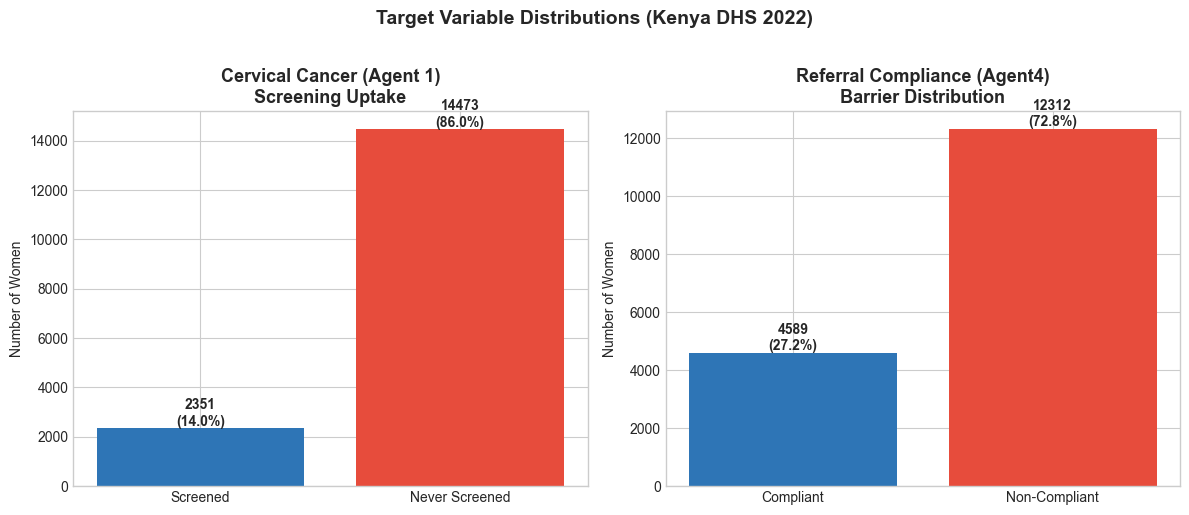

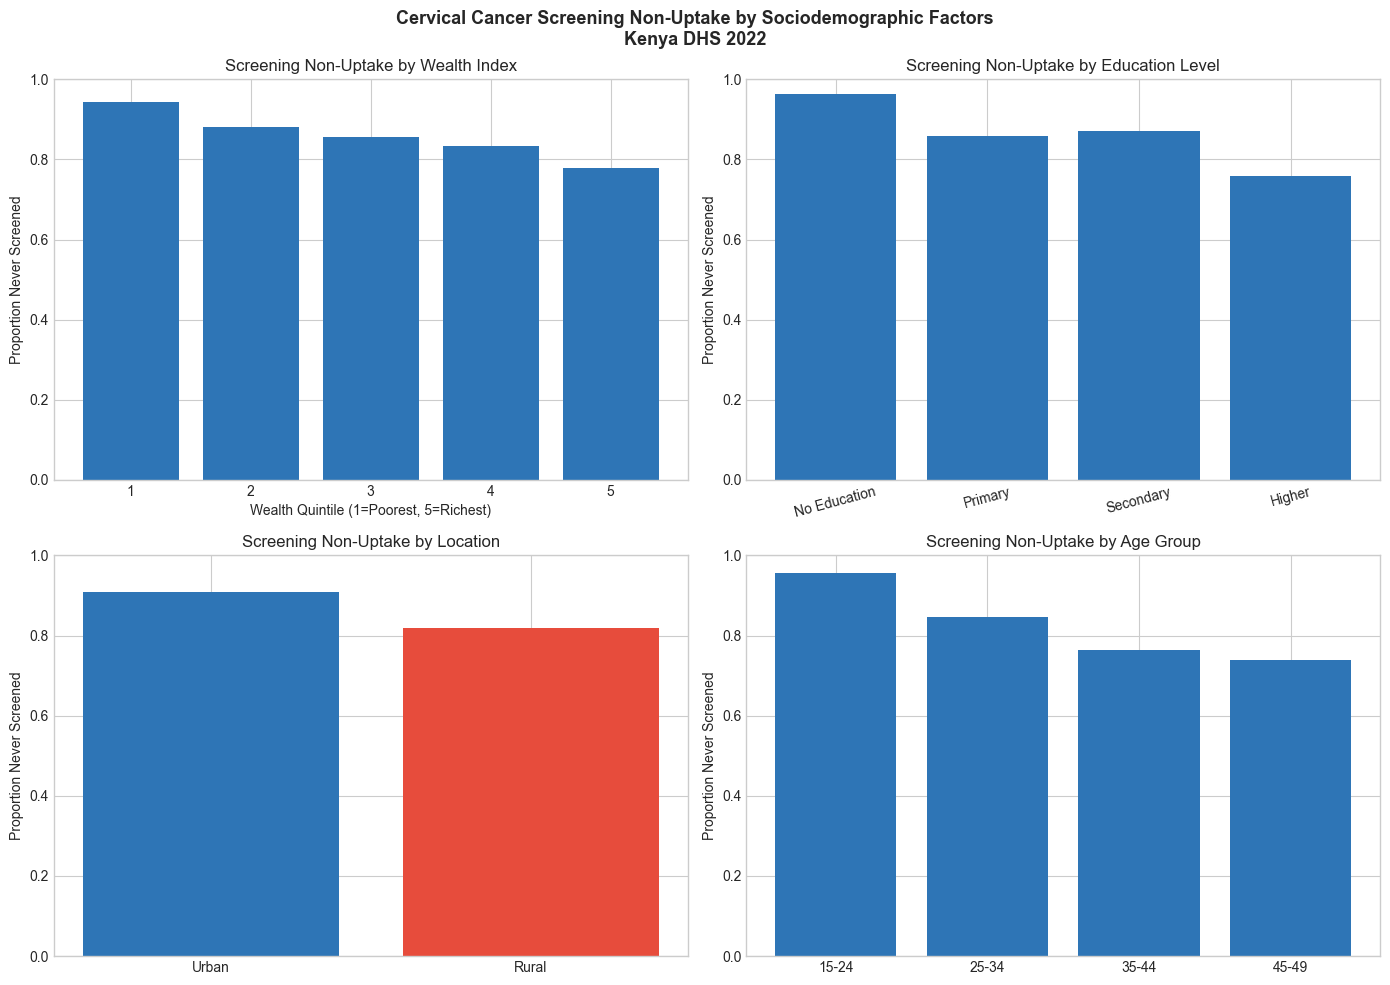

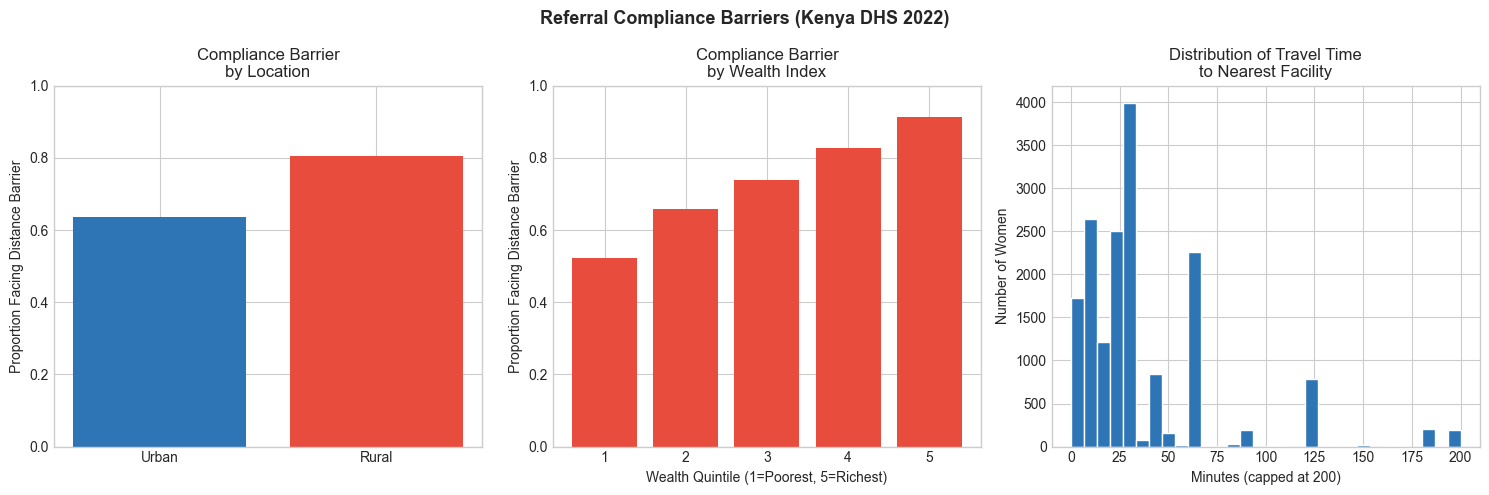


All EDA figures saved to outputs/figures/


In [11]:
# Setting style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#2E75B6', '#E74C3C']
fig_path = '../outputs/figures/'

# Figure 1: Class Distribution of Both Agents
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Agent 1
axes[0].bar(['Screened', 'Never Screened'], 
            [2351, 14473], color=colors)
axes[0].set_title('Cervical Cancer (Agent 1)\nScreening Uptake', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Women')
for i, v in enumerate([2351, 14473]):
    axes[0].text(i, v + 100, f'{v}\n({v/16824*100:.1f}%)', 
                ha='center', fontweight='bold')

# Agent 4
axes[1].bar(['Compliant', 'Non-Compliant'], 
            [4589, 12312], color=colors)
axes[1].set_title('Referral Compliance (Agent4)\nBarrier Distribution', 
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Women')
for i, v in enumerate([4589, 12312]):
    axes[1].text(i, v + 100, f'{v}\n({v/16901*100:.1f}%)', 
                ha='center', fontweight='bold')

plt.suptitle('Target Variable Distributions (Kenya DHS 2022)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{fig_path}fig1_class_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Screening by Key Features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By wealth index
screen_by_wealth = df_agent1.groupby('v190')['target_screening'].mean()
axes[0,0].bar(screen_by_wealth.index, screen_by_wealth.values, 
              color='#2E75B6')
axes[0,0].set_title('Screening Non-Uptake by Wealth Index')
axes[0,0].set_xlabel('Wealth Quintile (1=Poorest, 5=Richest)')
axes[0,0].set_ylabel('Proportion Never Screened')
axes[0,0].set_ylim(0, 1)

# By education
screen_by_edu = df_agent1.groupby('v106')['target_screening'].mean()
edu_labels = ['No Education', 'Primary', 'Secondary', 'Higher']
axes[0,1].bar(edu_labels, screen_by_edu.values, color='#2E75B6')
axes[0,1].set_title('Screening Non-Uptake by Education Level')
axes[0,1].set_ylabel('Proportion Never Screened')
axes[0,1].set_ylim(0, 1)
axes[0,1].tick_params(axis='x', rotation=15)

# By rural/urban
screen_by_rural = df_agent1.groupby('rural')['target_screening'].mean()
axes[1,0].bar(['Urban', 'Rural'], screen_by_rural.values, 
              color=colors)
axes[1,0].set_title('Screening Non-Uptake by Location')
axes[1,0].set_ylabel('Proportion Never Screened')
axes[1,0].set_ylim(0, 1)

# By age group
df_agent1['age_group'] = pd.cut(
    df_agent1['v012'],
    bins=[14, 24, 34, 44, 49],
    labels=['15-24', '25-34', '35-44', '45-49']
)
screen_by_age = df_agent1.groupby('age_group', observed=True)['target_screening'].mean()
axes[1,1].bar(screen_by_age.index.astype(str), 
              screen_by_age.values, color='#2E75B6')
axes[1,1].set_title('Screening Non-Uptake by Age Group')
axes[1,1].set_ylabel('Proportion Never Screened')
axes[1,1].set_ylim(0, 1)

plt.suptitle('Cervical Cancer Screening Non-Uptake by Sociodemographic Factors\nKenya DHS 2022', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{fig_path}fig2_screening_by_features.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: Compliance Barriers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# By rural
comp_by_rural = df_agent4.groupby('rural')['target_compliance'].mean()
axes[0].bar(['Urban', 'Rural'], comp_by_rural.values, color=colors)
axes[0].set_title('Compliance Barrier\nby Location')
axes[0].set_ylabel('Proportion Facing Distance Barrier')
axes[0].set_ylim(0, 1)

# By wealth
comp_by_wealth = df_agent4.groupby('v190')['target_compliance'].mean()
axes[1].bar(comp_by_wealth.index, comp_by_wealth.values, color='#E74C3C')
axes[1].set_title('Compliance Barrier\nby Wealth Index')
axes[1].set_xlabel('Wealth Quintile (1=Poorest, 5=Richest)')
axes[1].set_ylabel('Proportion Facing Distance Barrier')
axes[1].set_ylim(0, 1)

# By minutes to facility
axes[2].hist(df_agent4['v483a'].clip(upper=200), 
             bins=30, color='#2E75B6', edgecolor='white')
axes[2].set_title('Distribution of Travel Time\nto Nearest Facility')
axes[2].set_xlabel('Minutes (capped at 200)')
axes[2].set_ylabel('Number of Women')

plt.suptitle('Referral Compliance Barriers (Kenya DHS 2022)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{fig_path}fig3_compliance_barriers.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nAll EDA figures saved to outputs/figures/")

**Key findings:** 
* 86% of Kenyan women have never been screened
* 72.8% face distance as a compliance barrier
* counterintuitively, urban women show higher non-uptake rates than rural women